# transformer from scratch


<div align=center>
<img src="https://machinelearningmastery.com/wp-content/uploads/2021/08/attention_research_1.png" width="300" height="400">
</div>

In [1]:
import torch
import torch.nn as nn
import math

## 1. input embedding

所有的model不能直接处理word。transformer embedding层的作用是将word首先转换为它在vocabulary中的位置，然后再将其转换为维度为d_model的向量，我们称其为embedding。处于不同位置的token对应的embedding

target：输入input_id转换为embedding。

In [ ]:
class InputEmbedding(nn.Module):
    def __init__(self, d_model: int, vocab_size: int):
        super(InputEmbedding, self).__init__()
        self.d_model = d_model
        self.vocab_size = vocab_size
        self.embedding = nn.Embedding(num_embeddings=vocab_size, 
                                      embedding_dim=d_model)
        
    def forward(self, x):
        return self.embedding(x) * math.sqrt(self.d_model)

In [ ]:
# test 

inputembedding = InputEmbedding(512, 40)

X = [[1 ,2], [3, 4]]
X = torch.tensor(X, dtype=torch.long)

embedding =inputembedding(X)
print(embedding, embedding.shape)

tensor([[[ 2.0439e+01,  2.8399e+01,  4.2968e+01,  ...,  1.5213e+01,
           1.3610e+01, -1.9715e+00],
         [-1.6063e+01, -8.3334e+00,  4.1516e+00,  ...,  3.7097e-02,
          -4.4020e+01,  5.4323e+00]],

        [[-7.1160e+00,  1.2442e-01, -2.7443e+01,  ...,  1.3024e+01,
           2.9822e+00, -2.6272e+01],
         [ 1.2480e+01,  9.3464e+00, -2.5400e+00,  ...,  3.1715e+01,
          -1.7329e+01,  3.3900e+01]]], grad_fn=<MulBackward0>) torch.Size([2, 2, 512])


## 2. Positional encoding

注意到input embedding并没有添加位置信息，而我们希望model不仅要理解token的意思，还要理解到它的上下文。所以位置编码的作用是让model理解token所处的位置信息

target:输入embedding，对其加上位置编码

In [ ]:
class PositionalEncoding(nn.Module):

    def __init__(self, d_model: int, max_seq_len: int, dropout: float):
        super(PositionalEncoding, self).__init__()

        self.d_model = d_model
        self.max_seq_len = max_seq_len
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_seq_len, d_model)
        # shape:(max_seq_len, 1)
        position = torch.arange(0, max_seq_len, dtype=torch.float).unsqueeze(1)
        # shape:(max_seq_len / 2, )
        # 为了数值稳定性：先在取对数进行运算，最后再取e变回来
        div_term = torch.exp(torch.arange(0, d_model, step=2, dtype=torch.float) 
                             * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # shape:(1,max_seq_len,d_model)
        # 因为我们的输入会添加一个维度batch, 所以这个是用来 广播
        pe = pe.unsqueeze(0) 
        
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        # x shape(batch, seq_len, d_model)
        # pe不是可学习参数

        # Attention
        # grad 是需要去学习理解的
        x = x + self.pe[:, :x.shape[1], :].requires_grad_(False)
        return self.dropout(x)
    
# 对算法的输出结果进行检查

pe = PositionalEncoding(512, 200, 0.2)
print(pe(torch.zeros((2, 3, 512))).shape)

torch.Size([2, 3, 512])


对上述算法的实现过程中运用了tensor的广播机制。用一句话来总结广播机制就是：将较小的维度广播至较大的维度
- 广播时从尾部维度(低维度)开始
- 两个tensor的维度
  - 相等
  - 其中一个tensor的维度尺寸为1
  - 其中一个tensor不存在这个维度

接下来总结一下广播机制下tensor设计的原则：
- 确保不保存重复数据
- 用unsqueeze将其中一个tensor的维度个数添加至指定维度个数

## 3. Layer Normalization

normalization的作用是归一化(旨在将数据调整到统一的尺度或分布，以提高模型的训练效果和稳定性)，而我们使用的归一化方法为layer normalization. 假设每个batch有n个item，layer normalization对每个item计算均值和方差进行归一化，为了数值稳定性(避免除0)在分母除方差时还会加上$\epsilon$. 对于transformer而言item即是每个token对应的embedding

此外，我们还将引入两个可学习的参数$\gamma$和$\beta$来让model自己调节值的大小

$$
\hat x_j = \frac{x_j-\mu_j}{\sqrt{\sigma_j^2+\epsilon}}
$$

In [11]:
x = torch.ones((1,2,3))
print(x, x.mean(dim=-1).shape, (x.mean(dim=-1, keepdim=True)).shape)

print(torch.ones(1).shape)
print(torch.ones(1))

tensor([[[1., 1., 1.],
         [1., 1., 1.]]]) torch.Size([1, 2]) torch.Size([1, 2, 1])
torch.Size([1])
tensor([1.])


In [ ]:
class LayerNormalization(nn.Module):
    def __init__(self, epsilon: float):
        super(LayerNormalization, self).__init__()
        
        self.epsilon = epsilon
        # 可学习的参数存放在nn.Parameter中
        self.gamma = nn.Parameter(torch.ones((1))) # Multiply
        self.beta = nn.Parameter(torch.zeros((1))) # Add

    def forward(self, x: torch.Tensor):
        # x (batch_size, sequence_length, d_model)
        mean = x.mean(dim=-1, keepdim=True)
        std = x.std(dim=-1, keepdim=True)
        return (x - mean) / (std + self.epsilon) * self.gamma + self.beta

In [18]:
x = torch.arange(0,10,dtype=torch.float).reshape((1,2,5))
ln = LayerNormalization(0.1)
output = ln(x)
print(output, output.shape)

tensor([[[-1.1897, -0.5948,  0.0000,  0.5948,  1.1897],
         [-1.1897, -0.5948,  0.0000,  0.5948,  1.1897]]],
       grad_fn=<AddBackward0>) torch.Size([1, 2, 5])


## 4. Feed-Forward Network

参考论文，就是两个全连接层中间再机上ReLU。论文的参数矩阵维度为$d_{ff}$=2048

$$
\text{FFN}(x)=\max(0,xW_1+b_1)W_2+b_2
$$

In [2]:
class FeedForwardBlock(nn.Module):
    
    def __init__(self, d_model: int, d_ff: int, dropout: float):
        super().__init__()

        self.d_ff = d_ff
        self.dropout = nn.Dropout(dropout)
        # Linear bias默认为true
        self.liner1 = nn.Linear(d_model, d_ff) 
        self.liner2 = nn.Linear(d_ff, d_model)

    def forward(self, x: torch.Tensor):
        # (batch, seq_len, d_model) ---> (batch, seq_len, d_ff) ----> (batch, seq_len, d_model)
        return self.liner2(self.dropout(torch.relu(self.liner1(x))))

In [3]:
x = torch.ones((2,3,512))
ffb = FeedForwardBlock(512,2048,0.5)
out = ffb(x)
print(x.shape)

torch.Size([2, 3, 512])


## 5. Multi-head Attention

attention is all your need!

$$
\begin{align}
    \text{Attention}(Q,K,V) &= \text{softmax}(\frac{QK^T}{\sqrt{d_k}})V \\
    \text{MultiHead}(Q,K,V) &= \text{Concat}(head_1 \dots head_h)W^o \\
    \text{head}_i &= \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)
\end{align}    
$$


multi-head attention 是在self attention的基础上引入了三个参数矩阵，并将处理后的Q,K,V分解为h个head


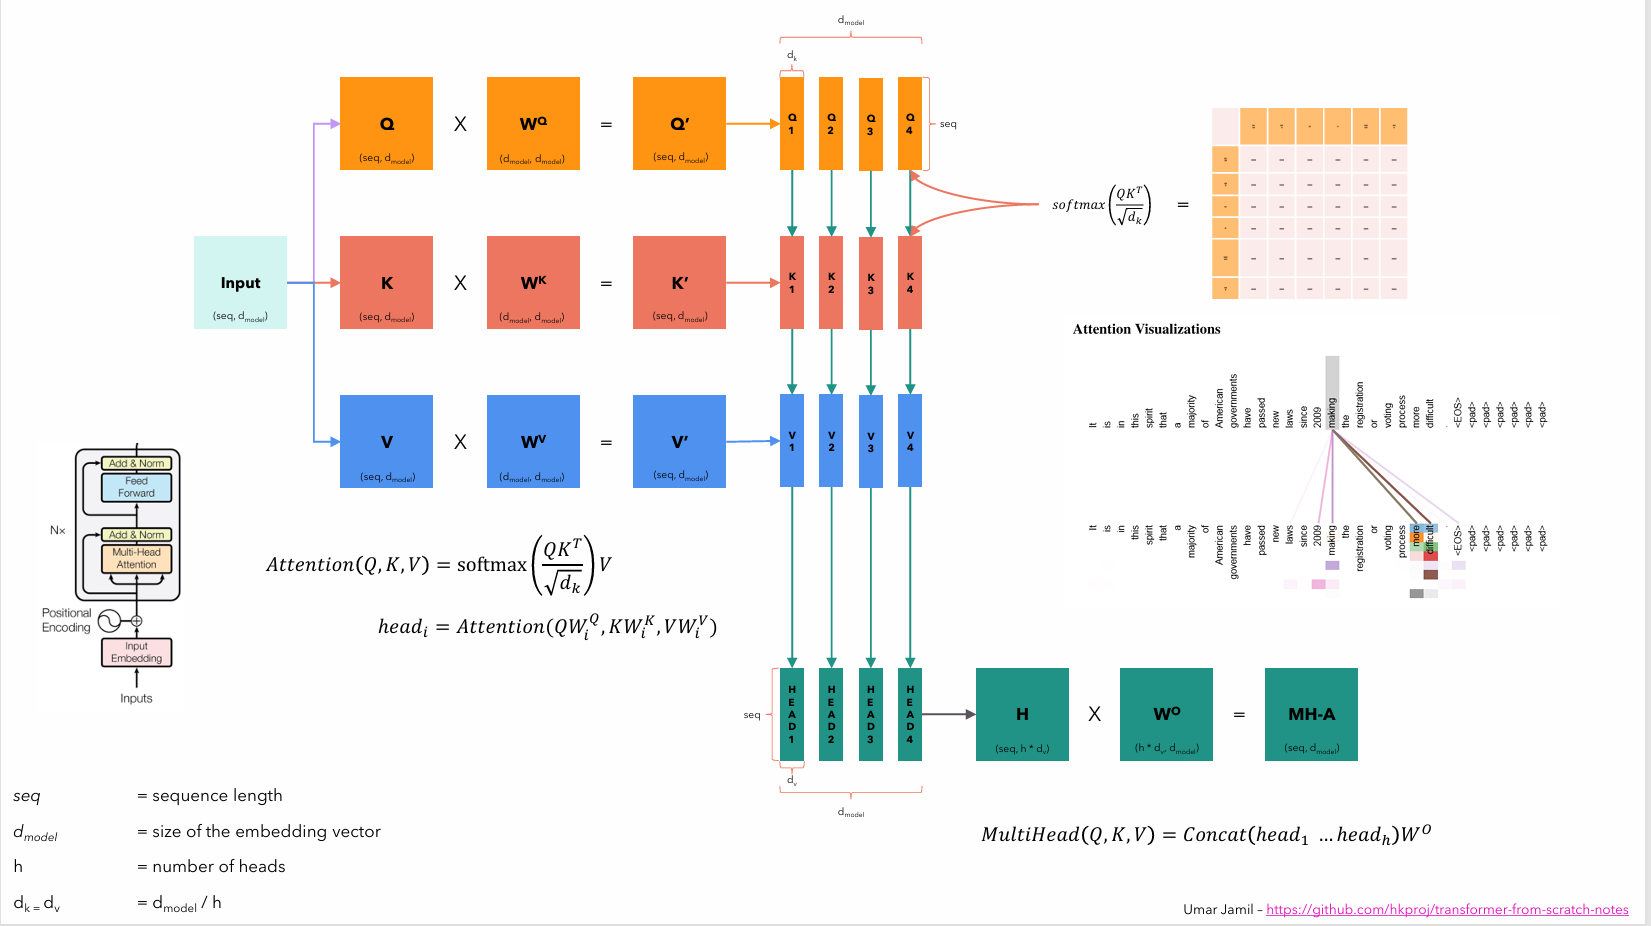

In [15]:
class MultiHeadAttentionBlock(nn.Module):
    
    def __init__(self, d_model: int, h: int, dropout: float):
        super().__init__()
        self.d_model = d_model
        self.h = h
        self.dropout = nn.Dropout(dropout)
        assert d_model % h == 0, "d_model is not divisible by h"
        # Note: / 返回浮点数, // 返回整数向下取整
        self.d_k = d_model // h  

        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

    @staticmethod
    def attention(query, key, value, mask, dropout: nn.Dropout):# -> tuple[Any, Any]:
        d_k = query.shape[-1]
        # (seq, d_k) @ (d_k, seq)
        attention_score = (query @ key.transpose(-2, -1)) / math.sqrt(d_k)

        # don't understand 
        if mask is not None:
            attention_score.masked_fill_(mask == 0, 1e-9)
    
        attention_score = attention_score.softmax(dim=-1)
        if dropout is not None:
            attention_score = dropout(attention_score)
        # (seq, seq) @ (seq, d_k)
        return (attention_score @ value), attention_score
    
    def forward(self, q, k, v, mask):
        query = self.W_q(q)
        key = self.W_k(k)
        value = self.W_v(v)

        # 分割为多个head
        # (batch, seq_length, d_model) ----> (batch, seq_length, h, d_k) ----> (batch, h, seq_length, d_k)
        # 交换seq_length和h的目的是为了方便接下来attention的计算：(seq, d_k)*(d_k, seq) 
        query = query.view(query.shape[0], query.shape[1], self.h, self.d_k).transpose(1, 2)
        key = key.view(key.shape[0], key.shape[1], self.h, self.d_k).transpose(1, 2)
        value = value.view(value.shape[0], value.shape[1], self.h, self.d_k).transpose(1, 2)
        
        x, attention_score = MultiHeadAttentionBlock.attention(query, key, value, mask, self.dropout)

        # (batch, h, seq, d_k) ----> (batch, seq, h, d_k) -----> (batch, seq. d_model)
        x = x.transpose(1, 2).contiguous().view(x.shape[0], -1, self.d_model)
        
        # (batch, seq, d_model) ---> (batch, seq, d_model)
        return x
        

In [16]:
ma = MultiHeadAttentionBlock(512, 4, 0.5)
input = torch.rand((10, 100, 512))
output = ma(input, input, input, None)
print(output.shape, '\n', output)

torch.Size([10, 100, 512]) 
 tensor([[[ 0.0317,  0.2072,  0.1969,  ..., -0.1100, -0.0549, -0.1082],
         [ 0.0618,  0.1664,  0.1467,  ..., -0.1139, -0.1122, -0.1612],
         [ 0.0462,  0.1934,  0.1683,  ..., -0.1143, -0.0970, -0.1415],
         ...,
         [ 0.0364,  0.1632,  0.1521,  ..., -0.1043, -0.0568, -0.1409],
         [ 0.0445,  0.1855,  0.1472,  ..., -0.1338, -0.0945, -0.1724],
         [ 0.0432,  0.1808,  0.1296,  ..., -0.1023, -0.0725, -0.1373]],

        [[ 0.0592,  0.2086,  0.1310,  ..., -0.0667, -0.1124, -0.1804],
         [ 0.0324,  0.2411,  0.1196,  ..., -0.1053, -0.1459, -0.2030],
         [ 0.0550,  0.2094,  0.1403,  ..., -0.0886, -0.1143, -0.1592],
         ...,
         [ 0.0398,  0.2299,  0.1532,  ..., -0.0883, -0.1188, -0.1704],
         [ 0.0965,  0.2195,  0.1500,  ..., -0.0636, -0.0970, -0.1736],
         [ 0.0535,  0.1950,  0.1274,  ..., -0.0915, -0.1379, -0.1880]],

        [[ 0.0734,  0.2415,  0.1406,  ..., -0.1340, -0.1336, -0.1439],
         [ 0.079

view 和 contiguous

- torch的很多操作会返回一个新的张量，但`view(shape)`会返回视图带着新的shape. 但它和原tensor共享底层数据
- view操作要求tensor必须是连续的，而view操作会返回一个非连续的tensor，故在连续的两次view操作之间必须使用`contiguous()`来使tensor连续